In [1]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [ ]:
#select computation device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Nutze Device: {device}")

Nutze Device: cpu


In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, DataLoader

#image preprocessing steps
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), #conevt to gray scale
    transforms.Resize((250, 250)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


# Load the complete dataset, each subfolder represents one material/class

gesamtdatensatz = ImageFolder(root='WRITE HERE YOUR FOLDER FOR TRAININGSDATA', transform=transform)
train_size = int(0.8 * len(gesamtdatensatz)) #80% training, 20% lerning
test_size = len(gesamtdatensatz) - train_size
train_data, test_data = random_split(gesamtdatensatz, [train_size, test_size])



# Number of images processed simultaneously during training
batch_size= 4

#Create DataLoader for training, shuffle=True randomizes image order each epoch
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)

# Create DataLoader for testing, shuffle=False keeps the order fixed during evaluati
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

In [4]:
image, label = train_data[0]
image.size()

torch.Size([1, 250, 250])

In [ ]:
class_names=['acr','pc','petg','sbe'] #define classes

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

#define Neural Network
class NeuralNet(nn.Module):
  def __init__(self):
    super().__init__()

    kernel_size = 5 # Define kernel_size inside __init__
    self.conv1 = nn.Conv2d(1, 12, kernel_size)
    self.pool1 = nn.MaxPool2d(2, 2) 

    self.conv2 = nn.Conv2d(12, 24, kernel_size)
    self.pool2 = nn.MaxPool2d(2, 2) 

    # Added a new convolutional and pooling layer
    self.conv3 = nn.Conv2d(24, 48, kernel_size=3) # New conv layer
    self.pool3 = nn.MaxPool2d(2, 2) # New pool layer

    # Adjusted fc1 input size due to new layer: 48 * 28 * 28 = 37632
    self.fc1 = nn.Linear(48 * 28 * 28, 64) # Updated input size
    self.fc2 = nn.Linear(64, 4) #4 output layers corresponding to the 4 matrial classes



  def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        # Added new pooling layer to forward pass
        x = self.pool3(F.relu(self.conv3(x))) # New layer in forward pass
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

#create neural network, move ot to the selected device
net = NeuralNet().to(device)

In [ ]:
net = NeuralNet()
learning_rate = 0.001
momentum1 = 0.9
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=momentum1)


In [ ]:
# Number of training epochs: One epoch means that the entire training dataset is passed through the network once

epochs = 25

#training loop
for epoch in range (epochs):
  print(f'Training epoch {epoch+1}')
  running_loss = 0.0
  for i, data in enumerate(train_loader):
    inputs, labels = data

    optimizer.zero_grad()
    outputs = net(inputs)
    loss = loss_function(outputs, labels)
    loss.backward()
    optimizer.step()


    running_loss += loss.item()
  print(f'Loss: {running_loss/len(train_loader):.4f}')

Training epoch 1
Loss: 0.9681
Training epoch 2
Loss: 0.6769
Training epoch 3
Loss: 0.5967
Training epoch 4
Loss: 0.5322
Training epoch 5
Loss: 0.4794
Training epoch 6
Loss: 0.4552
Training epoch 7
Loss: 0.3745
Training epoch 8
Loss: 0.3013
Training epoch 9
Loss: 0.2293
Training epoch 10
Loss: 0.1448
Training epoch 11
Loss: 0.1362
Training epoch 12
Loss: 0.0558
Training epoch 13
Loss: 0.0320
Training epoch 14
Loss: 0.0235
Training epoch 15
Loss: 0.0114
Training epoch 16
Loss: 0.0067
Training epoch 17
Loss: 0.0032
Training epoch 18
Loss: 0.0024
Training epoch 19
Loss: 0.0019
Training epoch 20
Loss: 0.0012
Training epoch 21
Loss: 0.0009
Training epoch 22
Loss: 0.0007
Training epoch 23
Loss: 0.0006
Training epoch 24
Loss: 0.0005
Training epoch 25
Loss: 0.0004


In [ ]:
# Save the trained model parameters to a .pth file
torch.save(net.state_dict(), 'WRITE HERE YOUR FOLDER FOR THE TRAININGS FOLDER .pth')

# Load the complete dataset
gesamt_datensatz = ImageFolder(
    root="WRITE HERE YOUR FOLDER FOR TRAININGSDATA",
    transform=transform
)

# Display the mapping between class names and numerical labels to check the order of classes
print(gesamt_datensatz.class_to_idx)

{'acr': 0, 'pc': 1, 'petg': 2, 'sbe': 3}


In [ ]:
net = NeuralNet()
net.load_state_dict(torch.load('WRITE HERE YOUR FOLDER FOR THE TRAININGS FOLDER .pth'))

<All keys matched successfully>

In [ ]:
correct = 0
total = 0

# Switch the network to evaluation mode
net.eval()
with torch.no_grad():
  for data in test_loader:
    images, labels = data
    outputs = net(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

# Calculate classification accurac
accuracy = 100 * correct / total
print(f'Accuracy on the test set: {accuracy:.2f}%')


Accuracy on the test set: 90.79%


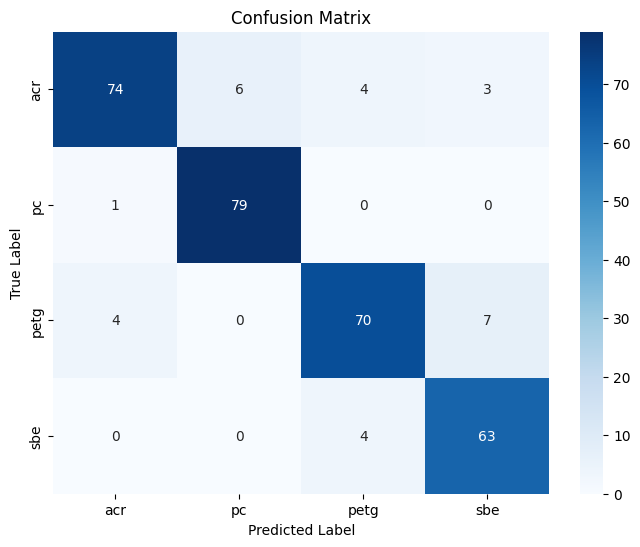

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Define class_names here to ensure it's always available
class_names=['acr','pc','petg','sbe']

all_labels = []
all_predicted = []

net.eval() # Set the model to evaluation mode
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.tolist())
        all_predicted.extend(predicted.tolist())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predicted)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()